# CLIPS Constructs

Refer details from lecture notes 6.

# Section A: Agenda

In [9]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# define template
# slot = only accepting one value (name John)
# ?variable = single field wild card (?name John)
# multi slot = can accept more than one value (name John Jenny Julie)
# $?variable = multifield wild card ($?name John Jenny Julie)
env.build("""(deftemplate person
           (multislot name)
           (multislot children))""")

# define fact
# some-people = name of the facts
env.build("""(deffacts some-people
           (person (name John Q. Public)
                   (children Jane Paul Mary))
           (person (name Jack R. Public)
                   (children Risk)))""")

# define rule
# print children = name of the rule
# if person have $?name and $?children, then print line
env.build("""(defrule print-children
           (person (name $?name)
                   (children $?children))
        =>(printout t $?name " has children " $?children
                     crlf))""")

env.reset()

# Method 1: Display agenda
# LIFO order for deffacts
# active = env.activations()
# i = 1
# for act in active:
#     print(f"Fire {i} : Rule {act.name}-{act.salience}")
#     i+=1
    
# Method 2: Use the command in CLIPS
# agenda = a list of activated rules that has been fired
env.eval("(agenda)")
env.run()

# After perform run, the agenda will be cleared automatically


0      print-children: f-2
0      print-children: f-1
For a total of 2 activations.
(Jack R. Public) has children (Risk)
(John Q. Public) has children (Jane Paul Mary)


2

<!-- # Section B: Pattern Matching -->

1. **Fire rule unconditionally**

In [10]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup 
                  (animal dog) (animal cat) (animal duck) (animal turtle) ;animal
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) ;warm-blooded
                  (lays-eggs duck) (lays-eggs turtle) 
                  (child-of dog puppy) (child-of cat kitten) (child-of turtle hatchling))""")

# since no facts required, then will directly print the line
env.build("""(defrule animal
  =>
  (printout t "animal found" crlf))""")

env.reset()
env.run()

animal found


1

2. **Pattern-matching wildcards**

In [12]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

# single-field wildcard (?). E.g. (animal cat)
# multifield wildcard ($?). E.g. (animal cat dog)
# (animal ?) = match anything that have animal fact-name
env.build("""(defrule animal
  (lays-eggs ?)
  =>
  (printout t "animal found" crlf))""")

env.reset()
env.run()

animal found
animal found


2

3. Display **pattern-matching variable**

In [13]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

# any 'animal' that match will return the value
env.build("""(defrule list-animals
(animal ?name)
=>
(printout t ?name " found" crlf))""")

env.reset()
env.run()

turtle found
duck found
cat found
dog found


4

4. **Fact assertion** for **pattern-matching variable**

In [14]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

env.build("""(defrule mammal
  (animal ?name)  ;match every animal (fact-name)
  (warm-blooded ?name)  ;match with warm-blood
  (not (lays-eggs ?name)) ;match any not lays-eggs
  =>
  (assert (mammal ?name)) ;assert new facts
  (printout t ?name " is a mammal" crlf))""")

env.reset()
env.run()


cat is a mammal
dog is a mammal


2

5. **Retract fact** in rules

In [15]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

# ?fact = variable that entire matched fact/value
# <- = fact binding operator
#    = bind entire facts/value into ?fact
env.build("""(defrule remove-warm-blooded
  ?fact <- (warm-blooded ?) ;save to ?fact
  =>
  (printout t "retracting " ?fact crlf)
  (retract ?fact))""")  # retract = remove the fact

env.reset()
env.run()

for fact in env.facts():
  print(fact)

retracting <Fact-7>
retracting <Fact-6>
retracting <Fact-5>


(animal dog)
(animal cat)
(animal duck)
(animal turtle)
(lays-eggs duck)
(lays-eggs turtle)
(child-of dog puppy)
(child-of cat kitten)
(child-of turtle hatchling)


# Section C: Field Constraints and Connective Constraints

In [16]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate person
               (slot name)
               (slot eyes)
               (slot hair))""")

# rule 1
#Find a person with blue eyes.
env.build("""(defrule find-blue-eyes
               (person (name ?name)
                       (eyes blue))
             =>(printout t ?name " has blue eyes." crlf))""")

# rule 2
# Find a person without brown hair.
env.build("""(defrule find-without-brown-hair
               (person (name ?name)
                       (hair ~brown)) ;~ = not, not brown
             =>(printout t ?name " does not have brown hair" crlf))""")

# rule 3
#Find a person with either black or brown hair.
env.build("""(defrule find-black-or-brown-hair
               (person (name ?name)
                       (hair black|brown)) ;black or brown
             =>(printout t ?name " has dark hair" crlf))""")

# rule 4
#Find a person with either black or brown hair. Specify the color of the hair.
# ?color& = conditional variable binding
#         = check the condition and save for future usage (eg. print in out)
env.build("""(defrule find-black-or-brown-hair
               (person (name ?name)
                       (hair ?color& black | brown)) ;check either black or brown, then saev value into ?color&
             =>(printout t ?name " has " ?color " hair" crlf))""")

# rule 5
#Find a person with neither black nor brown hair. Specify the color of the hair.
env.build("""(defrule find-black-nor-brown-hair
               (person (name ?name)
                       (hair ?color& black & ~brown))
             =>(printout t ?name " has " ?color " hair" crlf))""")

env.reset()

# LIFO
env.assert_string('(person (name Tawfeeq)(eyes blue))') # Rule 1, 2
env.assert_string('(person (name Kaviraj)(hair black))') # Rule 4, 5 (rule 3被4取代了因為name一樣)
env.assert_string('(person (name "Siti Nabila")(hair brown))') # Rule 4
                  
env.run()

Siti Nabila has brown hair
Kaviraj does not have brown hair
Kaviraj has black hair
Kaviraj has black hair
Tawfeeq has blue eyes.
Tawfeeq does not have brown hair


6

# Section D: Predicate Field Constraints

In [25]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

#Predicate Field Constraints, (height ?height&:(< ?height 12))
env.build("""(defrule sum-rectangles
                (rectangle (height ?height&:(> ?height 0)&:(< ?height 12)) (width ?width&:(> ?width 5)))
                ; rectangle = template name, refer to template 'rectangle'
                
                ; height = slot name
                ; ?height = variable
                ; &: = ading condition
                ; (> ?height 0) = ?height > 0
                ; (< ?height 12) = ?height < 12
          
                ; width = slot name
                ; ?width = variable
                ; &: = adding condition
                ; (> ?width 5) = ?width > 5
              =>
             (printout t "Rectangle meets the size criteria" crlf))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()

for fact in env.facts():
   print(fact)

Rectangle meets the size criteria


(rectangle (height 5) (width 10))


# Section E: Return Value Constraints

In [29]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

#Return Value Constraints =, ~=
# (width = (* 2 ?height) === check if width = (2 * height)
env.build("""(defrule check-size
               (rectangle (height ?height) (width = (* 2 ?height))) ;true, true
              =>(printout t "Verified width is double of height" crlf))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()


Verified width is double of height


1

# Section F: Test Construct

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Define a simple rule
# check 10 >= 5
# if true then print the line
env.build("""
(defrule example
  (test (>= 10 5))
  =>
  (printout t "Rule fired!" crlf))
""")

env.reset()

env.run()


# Section G: Modify Fact in Rule ( <- )

In [30]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

# ?r = bind the fact into the variables
# modify = modify the value in facts
env.build("""(defrule sum-rectangles
                 ;; assign the fact value to a variable
                 ?r<-(rectangle (height ?height) (width ?width))
             =>
             ;; modify the fact slot value 
             (modify ?r (width 30)))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()

for fact in env.facts():
    print(fact)

(rectangle (height 5) (width 30))


# Section H: Return Values from Rule

In [31]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

env.build("""(defrule sum-rectangles
                 (rectangle (height ?height) (width ?width))
              =>
            (assert (area (* ?height ?width))))""") # assert a new facts, fact-name is area
                                                    # value of (height * width)

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()

for fact in env.facts():
    if fact.template.name == "area":
        print('Area:' + str(fact[0]))

Area:50


# Section I: Built-in Functions & Expressions

1. Evaluate mathematic **expression**

In [33]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# In CLIPS (assert (sum (+ 3 5 7)))
# 3 + 5 + 7
env.eval('(+ 3 5 7)')

# Minus
env.eval('(- 5 3)')

# Multiply
env.eval('(* 5 3)')

# Division
env.eval('(/ 5 2)')

# Power of
env.eval('(** 2 5)')

# Sqrt of
env.eval('(sqrt 8)')

# Log base 10
env.eval('(log10 8)')

# Mod
env.eval("(mod 10 7)")

# Floor Division ??????
#env.eval('(// 5 2)')

# Floor Division - Mixture Python with CLIPS
# (5 // 2) * 1
env.eval(f'(* {5 // 2} 1)')



2

2. Evaluate mathematic **expression** with **fact assertion**

In [34]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.reset()

# f = f-string
value = env.eval('(+ 3 5 7)')
env.assert_string(f"(sum {value})")

# Mixture of Python and clipspy
env.assert_string(f"(sum {3 + 5 + 7})")

env.run()

for fact in env.facts():
    print(fact)

(sum 15)


3. **Summing values** in rules

In [35]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# ?n1 = 1
# ?n2 = 2
env.build("""(defrule calculate-sum
                   (sum ?n1 ?n2)
             => (printout t (+ ?n1 ?n2) crlf))""") # ?n1 + ?n2

env.reset()

env.assert_string('(sum 1 2)')

env.run()

3


1

* This will make the infinity loop

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""
(deftemplate rectangle
    (slot height)
    (slot width))
""")

env.build("""(deffacts initial-information
                (rectangle (height 10) (width 6))
                (rectangle (height 7) (width 5))
                (rectangle (height 6) (width 8))
                (rectangle (height 2) (width 5))
                (sum 0))""")

env.build("""(defrule sum-rectangles
                (rectangle (height ?height) (width ?width))
                ?sum <- (sum ?total)
                =>
                (retract ?sum)
                (assert (sum (+ ?total (* ?height ?width)))))
        """)

# infinity loop is because the rule sum-rectangle keep re-asserting the sum fact with update value in each interatiion
env.reset()

env.run()

* Fix it!

In [1]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""
(deftemplate rectangle
    (slot height)
    (slot width))
""")

env.build("""(deffacts initial-information
                (rectangle (height 10) (width 6))
                (rectangle (height 7) (width 5))
                (rectangle (height 6) (width 8))
                (rectangle (height 2) (width 5))
                (sum 0))""")

env.build("""(defrule sum-rectangles
                (rectangle (height ?height) (width ?width))
              => (assert (add-to-sum (* ?height ?width))))""")

env.build("""(defrule sum-areas
                ?sum<-(sum ?total)
                ?new-area<-(add-to-sum ?area)
              => (retract ?sum ?new-area)
                 (assert (sum (+ ?total ?area))))""")

env.reset()

env.run()

env.eval('(facts)')

f-1     (rectangle (height 10) (width 6))
f-2     (rectangle (height 7) (width 5))
f-3     (rectangle (height 6) (width 8))
f-4     (rectangle (height 2) (width 5))
f-13    (sum 153)
For a total of 5 facts.


# Section J: Create a User-Defined Function

1. Calling a **user-defined function**.

In [2]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

"""
def calculate-area(length, width):
    return (length * width)

calculate-area(2, 3)
"""

# function name = calculate-area
# (?length ?width) = parameter of function
#                  = placeholder for values will be passed in
env.build("""(deffunction calculate-area 
                       (?length ?width) (* ?length ?width))""")

# (assert (area (calculate-area 2 3)))
env.assert_string(f"(area (calculate-area 2 3))")

#area= env.eval(f"(calculate-area 2 3)")
#env.assert_string(f"(area {area})")

env.run()

for fact in env.facts():
    print(fact)

(area 6)


2. **Passing data** in a **user-defined function** with **parameter values** 

In [3]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffunction calculate-area(?x ?y)
                       (return (* ?x ?y)))""")

# env.build("""(deffunction main()
#                 (printout t "Area = " (calculate-area 3 5)))""")
# env.eval("(main)")

#(deffunction main()
#        (printout t "Area = " (calculate-area 3 5)))
#(main)"

value=env.eval("(calculate-area 3 5)")
print("Area = ", value)


Area =  15


3. Return **tuple** from **user-defined function**. Return more than one values.

In [4]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# create $ = like array in python
env.build("""(deffunction coordinate(?x ?y)
                       (return (create$ ?x ?y)))""")

value=env.eval("(coordinate 3 5)")
print("Area = ", value)


Area =  (3, 5)


# Section K: Global Variables

In [5]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# ?*x* = syntax for global variable
env.build("""(defglobal ?*x* = 10)""")

env.reset()

# 10 * 2
# ?*x* multiply by 2
env.assert_string("""(value (* ?*x* 2))""")

env.run()

for fact in env.facts():
    print(fact)

(value 20)


# Section L: Bind Functions

In [6]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# bind = assign value to the variable
# 'name' bind(assign) to the ?response variable
env.build("""(defrule get-name
             =>(printout t "What is your name? " crlf)
               (bind ?response "Tee Xue Ni")
               (printout t "I'm " ?response crlf)
               (bind ?response "Lim Hui Jun")
               (printout t "Sorry, I'm " ?response crlf))""")

env.reset()

env.run()


What is your name? 
I'm Tee Xue Ni
Sorry, I'm Lim Hui Jun


1

# Section M: Logical Condition

In [7]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.reset()

# methid 1
# (assert (status (if (> 2 1) then "valid" else "invalid"))
# if 2 > 1, then "valid", otherwise "invalid"
value = env.eval('(if (> 2 1) then "valid" else "invalid")')
env.assert_string(f"(status {value}))")

# method 2
# Mixture of Python and clipspy
#env.assert_string(f"(status {'valid' if 2 > 1 else 'invalid'})")

# method 3
#py_logical_condition = 'valid' if 2 > 1 else 'invalid'
#env.assert_string(f"(status {py_logical_condition})")

for fact in env.facts():
    print(fact)

(status valid)


# Section N: Exists Condition

In [8]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate emergency (slot type))""")

# exists(emergency) = check if at least one fact call "emergency"
# (not (operator-alert)) = check if "operator-alert" fact doesn't exist
env.build("""(defrule operator-alert-for-emergency
                (exists (emergency)) ;true
                (not (operator-alert)) ;true
             =>
                (printout t "Emergency: Operator Alert" crlf)
                (assert (operator-alert)))""") # assert new fact

env.reset()

env.assert_string("(emergency (type 'fire'))")

env.run()


Emergency: Operator Alert


1

# Section O: Forall

In [11]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate emergency 
               (slot type)
               (slot location))""")

env.build("""(deftemplate fire-squad 
               (slot name)
               (slot location))""")

env.build("""(deftemplate evacuated 
               (slot building))""")

# Define the rule using `forall`
# syntax = (forall condition (and condition2 condition))
# formal = check if for all facts match condition1, then subcondition block also true
env.build("""
(defrule all-fires-handled
   (forall
      (emergency (type fire) (location ?loc)) ; condition 1
      (and
         (fire-squad (location ?loc)) ;condition2
         (evacuated (building ?loc)))) ;condition3
   =>
   (printout t "All fire emergencies are handled: firefighters are present, and buildings are evacuated." crlf))
""")

# for each emergency type fire at location ?loc, the following must be true

# Assert facts
env.assert_string("(emergency (type fire) (location building-1))")
env.assert_string("(emergency (type fire) (location building-2))")
env.assert_string("(fire-squad (name squad1) (location building-1))")
env.assert_string("(fire-squad (name squad2) (location building-2))")
env.assert_string("(evacuated (building building-1))")
env.assert_string("(evacuated (building building-2))")

env.run()


All fire emergencies are handled: firefighters are present, and buildings are evacuated.


1

# Exercises:

1. Differentiate **(name ?response)**, **(bind ?response "abc")**, **(?response<-(animal 'Garfield'))** in **defrule**.

In [ ]:
#Hints:
#1. (name ?response) - 
#2. (bind ?response "abc") - 
#3. (?response<-(animal 'Garfield')) - 

2. Rewrite the expression **10+4*19-35/12** in CLIPS notation and verify that you get the **result 83.0833**.

In [14]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#
env.eval('(- (+ 10 (* 4 19)) (/ 35 12))')


83.08333333333333

3. Write an expert system that gets user input and **gives advice** on the discount rate given.

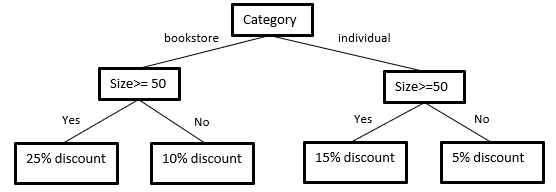

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#
env.build("""(defrule dis25
                (category ?category)
                (size ?size)
                (test (>= ?size 50))
              =>
             (printout t "Call AA!" crlf))""")

4. Write a rule based expert system to determine **even number** when user provide the inputs. (**Hints**: Must use **defrule** without calling **user-defined function**)

In [23]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#
env.build("""(defrule determine-even
          (and (number ?num)
               (test (= (mod ?num 2) 0))
          )
          =>
          (printout t ?num " is even number" crlf)
          )""")

env.reset()

value = int(input("Enter number: "))
env.assert_string(f"(number {value})")

env.run()

4 is even number


1

5. Define two **deftemplate** (**student** and **programme**) and simulate the **left join**, **right join** and **outer join** implementation.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#